<a href="https://colab.research.google.com/github/virtuosa0714/casa0018/blob/main/Week7/CASA0018_7_lab_result.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deep Learning for Sensors Networks**
# Week 7 - Lab

This is your chance to try out RNNs on a real data set (light-400.csv). The data set contains 400 data points recorded by an indoor light sensor (light dependent resistor) over a period of about 20 days.

The data set can be found here:
https://github.com/djdunc/casa0018/tree/main/Week7

Download it to your local machine.

To get you started I've include some code to load the data into a Python dataframe and split the data into train and validate sets.

Your tasks is to build both a vanilla RNN and LSTM, train them on the data set and use them to perform forecasting. The tasks are outlined in more detail later in the notebook.



# Set up the imports

In [1]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator # Generates batches for sequence data
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import files
import tensorflow as tf

# Load sensor data from csv file

In [2]:

from google.colab import files
uploaded = files.upload()

Saving light-400.csv to light-400.csv


# Load into a dataframe

401
     light
0     30.0
1      9.2
2      2.4
3      2.4
4      5.4
..     ...
396   46.0
397   46.0
398   33.4
399    8.4
400    6.0

[401 rows x 1 columns]


<Axes: >

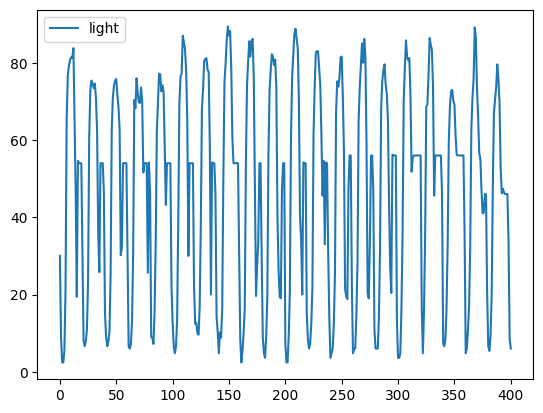

In [3]:
df = pd.read_csv('light-400.csv')
print(len(df))
print(df)
df.plot()

# Split into Train and Validate sets

401
361
40


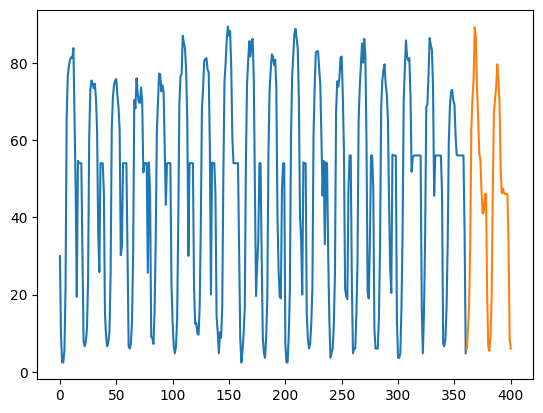

In [4]:
print(len(df))
val_percent = 0.1   # 10 percent of data
val_point = np.round(len(df)*val_percent)
val_index = int(len(df) - val_point)
train = df.iloc[:val_index]
val = df.iloc[val_index:]

print(len(train))
print(len(val))

plt.plot(train)
plt.plot(val)


# Normalise data sets

In [5]:
scaler = MinMaxScaler(copy=True, feature_range=(0, 1))
scaler.fit(train)
scaled_train = scaler.transform(train)
scaled_val = scaler.transform(val)

# Your Tasks

*   Using the lecture notebook as a guide, build and train a vanilla RNN, using a sequence length of 20
*   Check your model against the validation data set
*   Use your model to forecast 40 steps into the future

Repeat the above steps for a LSTM



In [15]:
# 定义参数
n_input = 20  # 使用前20个点预测第21个点
n_features = 1 # 只有一个特征（光照强度）
batch_size = 10 # 初始批量大小设为4

# 创建训练集生成器
generator = TimeseriesGenerator(scaled_train, scaled_train,
                                length=n_input, batch_size=batch_size)

# 创建验证集生成器
validation_generator = TimeseriesGenerator(scaled_val, scaled_val,
                                           length=n_input, batch_size=batch_size)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.1315 - val_loss: 0.0110
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0212 - val_loss: 0.0151
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0157 - val_loss: 0.0091
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0137 - val_loss: 0.0122
Epoch 5/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0130 - val_loss: 0.0081
Epoch 6/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0135 - val_loss: 0.0058
Epoch 7/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0154 - val_loss: 0.0078
Epoch 8/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0135 - val_loss: 0.0075


<Axes: >

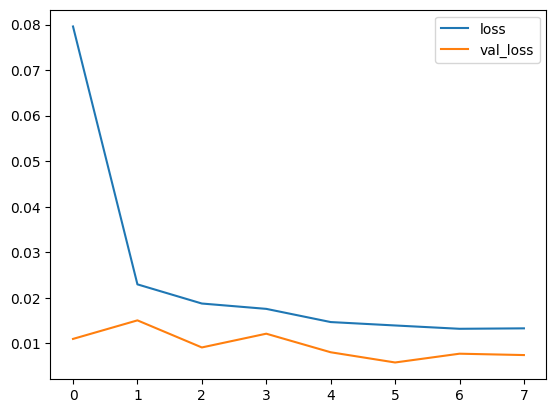

In [21]:
# 1. 定义模型
rnn_model = Sequential()
rnn_model.add(SimpleRNN(100, input_shape=(n_input, n_features)))
rnn_model.add(Dense(1)) # 输出层
rnn_model.compile(optimizer='adam', loss='mse')

# 2. 训练模型
# 设置早停机制防止过拟合
early_stop = EarlyStopping(monitor='val_loss', patience=2)
rnn_model.fit(generator, epochs=20, validation_data=validation_generator, callbacks=[early_stop])

# 3. 查看训练表现
losses = pd.DataFrame(rnn_model.history.history)
losses.plot()

In [26]:
# 1. 定义模型
lstm_model = Sequential()
lstm_model.add(LSTM(100, input_shape=(n_input, n_features)))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# 2. 训练模型
lstm_model.fit(generator, epochs=20, validation_data=validation_generator, callbacks=[early_stop])

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.1876 - val_loss: 0.0740
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0914 - val_loss: 0.0650
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0730 - val_loss: 0.0269
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0409 - val_loss: 0.0163
Epoch 5/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0319 - val_loss: 0.0143
Epoch 6/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0277 - val_loss: 0.0130
Epoch 7/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0260 - val_loss: 0.0132
Epoch 8/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0245 - val_loss: 0.0090
Epoch 9/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0211 - val_loss: 0.0100
Epoch 10/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0195 - val_loss: 0.0155


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━

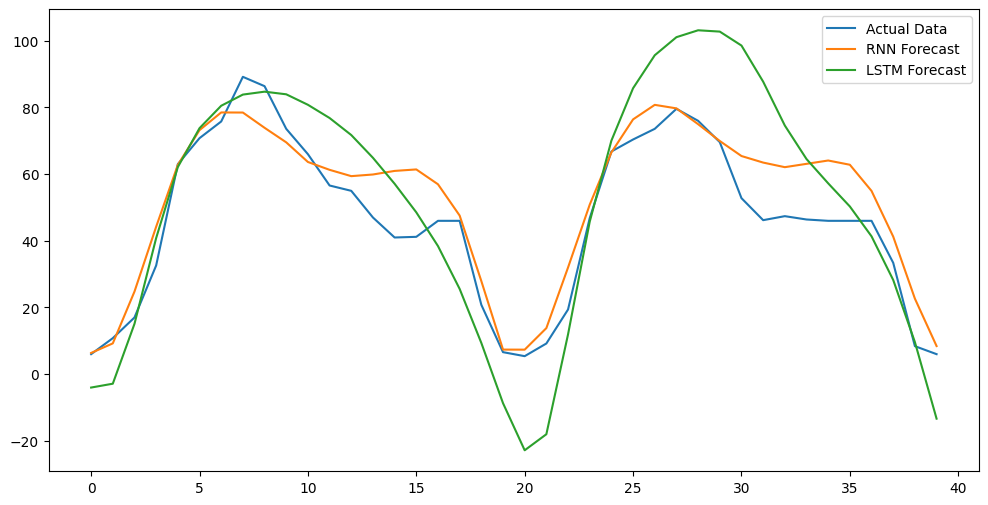

In [27]:
def forecast_future(model, train_data, n_input, steps=40):
    test_predictions = []
    # 获取训练集的最后 n_input 个点作为初始输入
    first_eval_batch = train_data[-n_input:]
    current_batch = first_eval_batch.reshape((1, n_input, n_features))

    for i in range(steps):
        # 预测当前步
        current_pred = model.predict(current_batch)[0]
        test_predictions.append(current_pred)

        # 更新 batch：加入预测值，去掉第一个值
        current_batch = np.append(current_batch[:,1:,:], [[current_pred]], axis=1)

    # 将结果逆归一化回原始数值范围
    return scaler.inverse_transform(test_predictions)

# 执行预测
rnn_forecast = forecast_future(rnn_model, scaled_train, n_input)
lstm_forecast = forecast_future(lstm_model, scaled_train, n_input)

# 可视化结果
plt.figure(figsize=(12,6))
plt.plot(val.values, label='Actual Data')
plt.plot(rnn_forecast, label='RNN Forecast')
plt.plot(lstm_forecast, label='LSTM Forecast')
plt.legend()

# Things to explore

*  Batch size - Try varying the batch size to, for example, 1 and 10. How does batch size affect model accuracy and training time? Why?

*  Number of RNN layers - what happens if you add a second recurrent layer to your model? Here is the code to do this for a vanilla RNN. The code for a LSTM is similar.
```
rnn_model.add(SimpleRNN(output_space, return_sequences=True, input_shape = (length , n_features)))
rnn_model.add(SimpleRNN(output_space))
```



